# A global machine-learning calibration of brGDGTs for reconstructing drought variability

Haichao Xie<sup>a</sup>, Jie Liang<sup>a,*</sup>, Ziru Sheng<sup>a</sup>, Ulrike Herzschuh<sup>c,d,e</sup>

<sup>a</sup> Group of Alpine Paleoecology and Human Adaptation (ALPHA), State Key Laboratory of Tibetan Plateau Earth System, Resources and Environment (TPESRE), Institute of Tibetan Plateau Research, Chinese Academy of Sciences, Beijing 100101, China

<sup>b</sup> University of Chinese Academy of Sciences, Beijing 100049, China

<sup>c</sup> Polar Terrestrial Environmental Systems, Alfred Wegener Institute Helmholtz Centre for Polar and Marine Research, Telegrafenberg, Potsdam 14473, Germany

<sup>d</sup> Institute of Environmental Science and Geography, University of Potsdam, Potsdam 14469, Germany

<sup>e</sup> Institute of Biochemistry and Biology, University of Potsdam, Potsdam 14476, Germany

<sup>*</sup> Corresponding author: Jie Liang (liangjie@itpcas.ac.cn)

## Notebook overview

This notebook develops a global soil brGDGT–summer SPEI calibration for reconstructing drought variability. It covers data preprocessing, model comparison, XGBoost optimization, performance evaluation, and application to independent western Asian soil samples.

## 1. Import Required Python Packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

from matplotlib.ticker import FormatStrFormatter
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.svm import SVR
from skopt import BayesSearchCV

## 2. Compare Machine-Learning Models

In [14]:


file_path = r"D:\ampling_points_with_spei.csv"

features = [
    "Ia", "Ib", "Ic",
    "IIa", "IIa.", "IIb", "IIb.", "IIc", "IIc.",
    "IIIa", "IIIa.", "IIIb", "IIIb.", "IIIc", "IIIc."
]
target = "Summer SPEI"

data = pd.read_csv(file_path)
data = data.dropna(subset=features + [target]).copy()

z_scores = (
    (data[target] - data[target].mean()) /
    data[target].std()
).abs()

data = data.loc[z_scores < 3].copy()

X = np.log1p(data[features])
y = data[target]

X_train, _, y_train, _ = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

models = {
    "XGBoost": xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "SVM": SVR(
        kernel="rbf",
        C=1.0,
        epsilon=0.1
    )
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X)

    predictions[name] = y_pred

    results.append({
        "Model": name,
        "R2": r2_score(y, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y, y_pred))
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

print(
    results_df.to_string(
        index=False,
        formatters={
            "R2": "{:.2f}".format,
            "RMSE": "{:.2f}".format
        }
    )
)

best_model = results_df.loc[0, "Model"]
best_r2 = results_df.loc[0, "R2"]
best_rmse = results_df.loc[0, "RMSE"]
y_pred_best = predictions[best_model]


        Model   R2 RMSE
      XGBoost 0.80 0.33
Random Forest 0.54 0.50
          SVM 0.43 0.55


In [15]:

file_path = r"D:\sampling_points_with_spei.csv"

features = [
    "Ia", "Ib", "Ic",
    "IIa", "IIa.", "IIb", "IIb.", "IIc", "IIc.",
    "IIIa", "IIIa.", "IIIb", "IIIb.", "IIIc", "IIIc."
]
target = "Summer SPEI"

data = pd.read_csv(file_path)
data = data.dropna(subset=features + [target]).copy()

z_scores = (
    (data[target] - data[target].mean()) /
    data[target].std()
).abs()

data = data.loc[z_scores < 3].copy()

X = np.log1p(data[features])
y = data[target]

X_train, _, y_train, _ = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

models = {
    "XGBoost": xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "SVM": SVR(
        kernel="rbf",
        C=1.0,
        epsilon=0.1
    )
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X)

    predictions[name] = y_pred

    results.append({
        "Model": name,
        "R2": r2_score(y, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y, y_pred))
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

print(
    results_df.to_string(
        index=False,
        formatters={
            "R2": "{:.2f}".format,
            "RMSE": "{:.2f}".format
        }
    )
)

best_model = results_df.loc[0, "Model"]
best_r2 = results_df.loc[0, "R2"]
best_rmse = results_df.loc[0, "RMSE"]
y_pred_best = predictions[best_model]


        Model   R2 RMSE
      XGBoost 0.80 0.33
Random Forest 0.54 0.50
          SVM 0.43 0.55


## 3. Optimize the XGBoost Calibration

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from matplotlib.ticker import FormatStrFormatter
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from skopt import BayesSearchCV


file_path =  r"D:\sampling_points_with_spei.csv"
features = [
    "Ia", "Ib", "Ic",
    "IIa", "IIa.", "IIb", "IIb.", "IIc", "IIc.",
    "IIIa", "IIIa.", "IIIb", "IIIb.", "IIIc", "IIIc."
]
target = "Summer SPEI"

data = pd.read_csv(file_path)
data = data.dropna(subset=features + [target]).copy()

z_scores = (
    (data[target] - data[target].mean()) /
    data[target].std()
).abs()

data = data.loc[z_scores < 3].copy()

X = np.log1p(data[features])
y = data[target]

X_train, _, y_train, _ = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

parameter_space = {
    "n_estimators": (50, 200),
    "learning_rate": (0.01, 0.20, "log-uniform"),
    "max_depth": (3, 10),
    "subsample": (0.50, 1.00),
    "colsample_bytree": (0.50, 1.00)
}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

bayes_search = BayesSearchCV(
    estimator=xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),
    search_spaces=parameter_space,
    n_iter=30,
    scoring="neg_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

bayes_search.fit(X_train, y_train)

best_parameters = dict(bayes_search.best_params_)

final_model = xgb.XGBRegressor(
    **best_parameters,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
cv_rmse = np.sqrt(-bayes_search.best_score_)

display_parameters = {
    name: (
        int(value)
        if name in {"n_estimators", "max_depth"}
        else round(float(value), 2)
    )
    for name, value in best_parameters.items()
}

print("Best parameters:")
for name, value in display_parameters.items():
    if name in {"n_estimators", "max_depth"}:
        print(f"{name}: {value}")
    else:
        print(f"{name}: {value:.2f}")



Best parameters:
colsample_bytree: 0.76
learning_rate: 0.04
max_depth: 10
n_estimators: 200
subsample: 1.00


## 4. Save the Trained Mode

In [12]:
# Refit and save the final XGBoost calibration
import joblib

final_model.fit(X, y)

model_file = "xgboost_model_spei.pkl"
joblib.dump(final_model, model_file)

print(f"Final XGBoost model saved to: {model_file}")

Final XGBoost model saved to: xgboost_model_spei.pkl


## 5. Inspect the Optimized XGBoost Parameters

In [13]:
import joblib

model = joblib.load("xgboost_model_spei.pkl")

parameters = model.get_params()

important_parameters = [
    "n_estimators",
    "learning_rate",
    "max_depth",
    "subsample",
    "colsample_bytree",
    "objective",
    "random_state"
]

print("XGBoost model parameters:")

for name in important_parameters:
    value = parameters.get(name)

    if isinstance(value, float):
        print(f"{name}: {value:.2f}")
    else:
        print(f"{name}: {value}")

XGBoost model parameters:
n_estimators: 200
learning_rate: 0.04
max_depth: 10
subsample: 1.00
colsample_bytree: 0.76
objective: reg:squarederror
random_state: 42


## 6. Visualize Feature Importance and brGDGT Distributions

C:\Users\jie liang\anaconda3\envs\myenv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\jie liang\anaconda3\envs\myenv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\jie liang\anaconda3\envs\myenv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt t

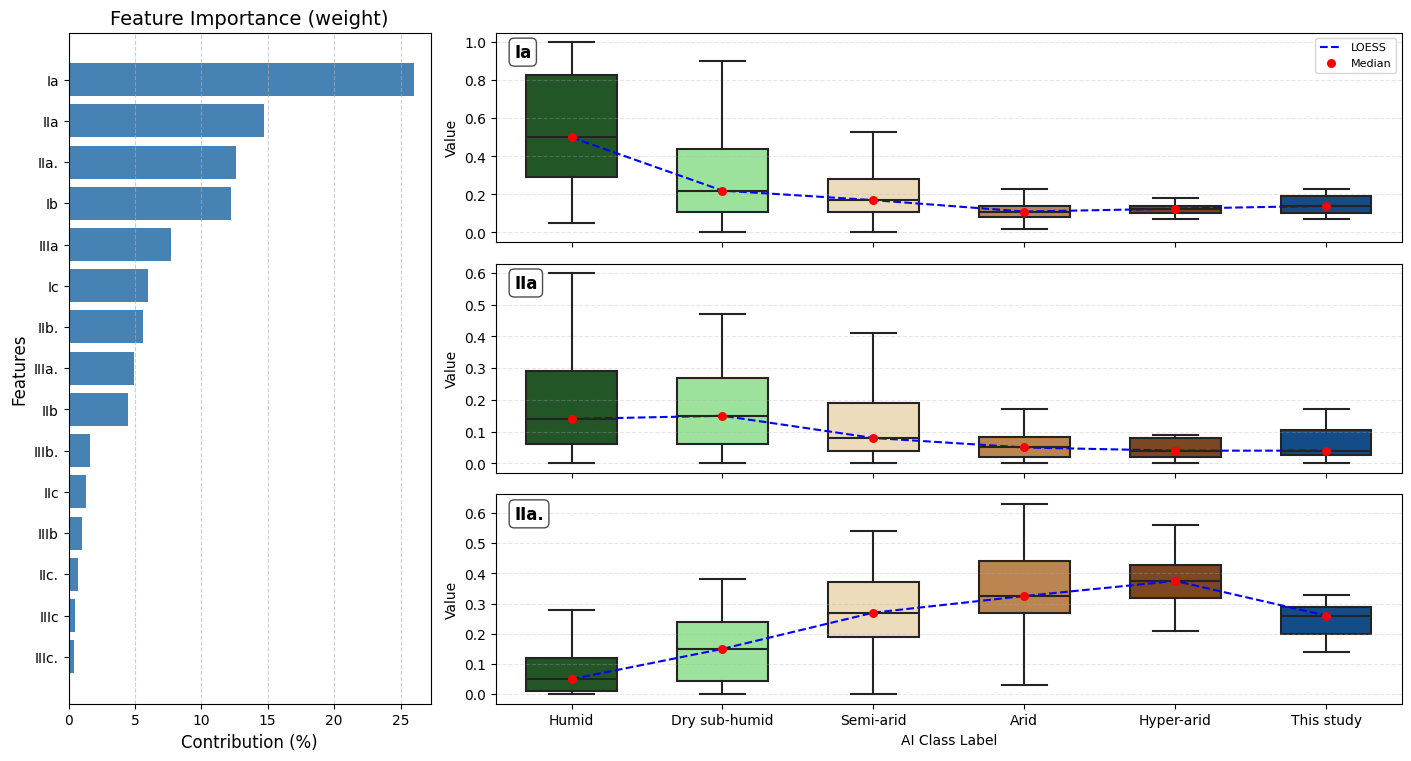

In [10]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.gridspec import GridSpec
from statsmodels.nonparametric.smoothers_lowess import lowess


# Load the XGBoost model and extract feature importance
model = joblib.load(
    r"D:\xgboost_model_spei.pkl"
)

booster = model.get_booster()
importance_type = "weight"
importance_scores = booster.get_score(
    importance_type=importance_type
)

features = np.array(list(importance_scores.keys()))
importance = np.array(
    list(importance_scores.values()),
    dtype=float
)
importance = importance / importance.sum() * 100

order = np.argsort(importance)
features = features[order]
importance = importance[order]


# Load and prepare the boxplot data
data_path = (r"D:\data")

world_data = pd.read_excel(
    f"{data_path}/World_Sampling_Points.xlsx"
)

study_data = pd.read_excel(
    f"{data_path}/Iran_Sampling_Points.xlsx"
)

study_data.columns = study_data.columns.str.replace(
    "'",
    ".",
    regex=False
)

study_data["AI_Class_Label"] = "This study"

all_data = pd.concat(
    [world_data, study_data],
    ignore_index=True
)

class_order = [
    "Humid",
    "Dry sub-humid",
    "Semi-arid",
    "Arid",
    "Hyper-arid",
    "This study",
    "Armenian topsoil"
]

present_classes = [
    category
    for category in class_order
    if category in all_data["AI_Class_Label"].dropna().unique()
]

all_data["AI_Class_Label"] = pd.Categorical(
    all_data["AI_Class_Label"],
    categories=present_classes,
    ordered=True
)

compounds = ["Ia", "IIa", "IIa."]

long_data = all_data.melt(
    id_vars="AI_Class_Label",
    value_vars=compounds,
    var_name="Compound",
    value_name="Value"
)

long_data = long_data.dropna(
    subset=["AI_Class_Label", "Value"]
)

long_data["Compound"] = pd.Categorical(
    long_data["Compound"],
    categories=compounds,
    ordered=True
)

long_data["x_pos"] = (
    long_data["AI_Class_Label"].cat.codes
)

median_data = (
    long_data
    .groupby(
        ["AI_Class_Label", "Compound"],
        observed=True
    )
    .agg(
        Median=("Value", "median"),
        x_pos=("x_pos", "first")
    )
    .reset_index()
)

colors = {
    "Humid": "#1B5E20",
    "Dry sub-humid": "#90EE90",
    "Semi-arid": "#F5DEB3",
    "Arid": "#CD853F",
    "Hyper-arid": "#8B4513",
    "This study": "#004C99",
    "Armenian topsoil": "#FF6600"
}

palette = {
    category: colors[category]
    for category in present_classes
    if category in colors
}


# Create the combined figure
n_compounds = len(compounds)

fig = plt.figure(
    figsize=(14, 2.5 * n_compounds),
    constrained_layout=True
)

grid = GridSpec(
    n_compounds,
    2,
    width_ratios=[1, 2.5],
    figure=fig
)

ax_left = fig.add_subplot(grid[:, 0])

ax_left.barh(
    features,
    importance,
    color="steelblue"
)

ax_left.set_title(
    f"Feature Importance ({importance_type})",
    fontsize=14
)
ax_left.set_xlabel("Contribution (%)", fontsize=12)
ax_left.set_ylabel("Features", fontsize=12)
ax_left.grid(
    axis="x",
    linestyle="--",
    alpha=0.6
)

right_axes = [
    fig.add_subplot(grid[index, 1])
    for index in range(n_compounds)
]

for index, compound in enumerate(compounds):
    ax = right_axes[index]

    compound_data = long_data[
        long_data["Compound"] == compound
    ]

    sns.boxplot(
        data=compound_data,
        x="AI_Class_Label",
        y="Value",
        order=present_classes,
        palette=palette,
        fliersize=0,
        width=0.6,
        ax=ax
    )

    compound_medians = (
        median_data[
            median_data["Compound"] == compound
        ]
        .sort_values("x_pos")
    )

    if len(compound_medians) >= 3:
        try:
            loess_result = lowess(
                compound_medians["Median"],
                compound_medians["x_pos"],
                frac=0.6,
                return_sorted=True
            )

            ax.plot(
                loess_result[:, 0],
                loess_result[:, 1],
                color="blue",
                linestyle="--",
                linewidth=1.5,
                label="LOESS"
            )

        except Exception as error:
            print(
                f"LOESS failed for {compound}: {error}"
            )

    ax.scatter(
        compound_medians["x_pos"],
        compound_medians["Median"],
        color="red",
        s=30,
        zorder=5,
        label="Median"
    )

    ax.text(
        0.02,
        0.95,
        compound,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        verticalalignment="top",
        horizontalalignment="left",
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.7
        }
    )

    ax.set_title("")
    ax.set_ylabel("Value", fontsize=10)
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    if index == n_compounds - 1:
        ax.set_xlabel("AI Class Label", fontsize=10)
        ax.tick_params(axis="x", rotation=0)
    else:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)

    if index == 0:
        ax.legend(
            loc="upper right",
            fontsize=8
        )

plt.show()

## 7. Apply the Calibration to Paleoclimate Records 

In [1]:
"""
Apply the trained XGBoost model to reconstruct summer SPEI for the
WeinanTang 2017 EPSL brGDGT dataset.

The output file contains the original data and reconstructed summer SPEI.
"""

from pathlib import Path

import joblib
import numpy as np
import pandas as pd


input_file = Path(
    r"D:\WeinanTang 2017_EPSL-brGDGT.csv"
)

model_file = Path("xgboost_model_spei.pkl")

output_file = input_file.with_name(
    "WeinanTang_2017_EPSL_reconstructed_summer_SPEI.csv"
)

features = [
    "Ia", "Ib", "Ic",
    "IIa", "IIa.", "IIb", "IIb.", "IIc", "IIc.",
    "IIIa", "IIIa.", "IIIb", "IIIb.", "IIIc", "IIIc."
]

data = pd.read_csv(input_file)

# Standardize prime symbols in column names
data.columns = data.columns.str.replace(
    "'",
    ".",
    regex=False
)

missing_features = [
    feature for feature in features
    if feature not in data.columns
]

if missing_features:
    raise ValueError(
        f"Missing required brGDGT variables: {missing_features}"
    )

if data[features].isna().any().any():
    missing_rows = data.index[
        data[features].isna().any(axis=1)
    ].tolist()

    raise ValueError(
        f"Missing brGDGT values detected in rows: {missing_rows}"
    )

if (data[features] < 0).any().any():
    raise ValueError(
        "Negative brGDGT values were detected. "
        "All predictors must be non-negative."
    )

X_new = np.log1p(data[features])

model = joblib.load(model_file)

if hasattr(model, "feature_names_in_"):
    model_features = list(model.feature_names_in_)

    if model_features != features:
        raise ValueError(
            "The predictor names or order do not match "
            "those used for model calibration."
        )

reconstructed_spei = model.predict(X_new)

data["Reconstructed summer SPEI"] = reconstructed_spei

data.to_csv(
    output_file,
    index=False
)

print(f"Samples reconstructed: {len(data)}")
print(
    "Reconstructed summer SPEI range: "
    f"{reconstructed_spei.min():.2f} to "
    f"{reconstructed_spei.max():.2f}"
)
print(f"Results saved to: {output_file}")

Samples reconstructed: 198
Reconstructed summer SPEI range: -0.20 to 0.95
